
Average Benchmark Results:
Algorithm: ML-KEM-1024
Average Encapsulation + Key Generation Time: 0.000255 seconds
Average Decapsulation + Key Extraction Time: 0.000684 seconds
Average Total Time: 0.000940 seconds
Shared Secrets Match: True
Derived Keys Match: True


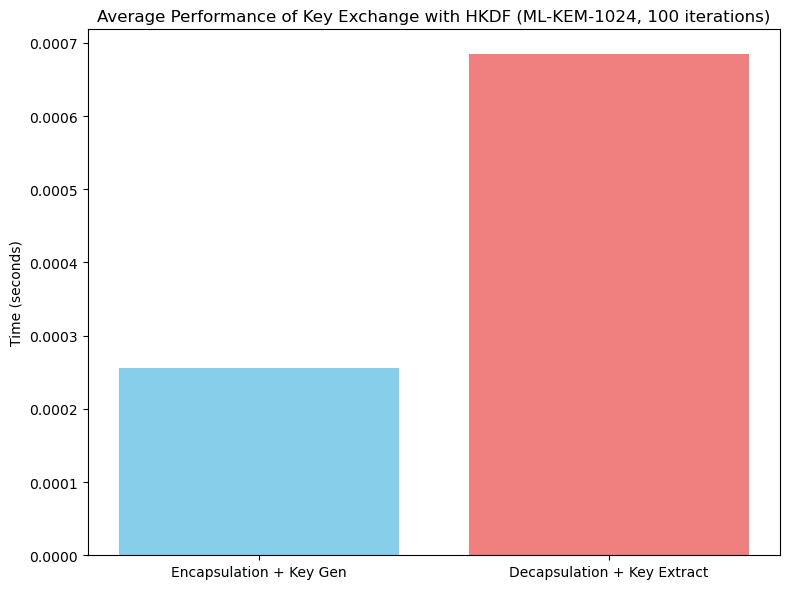

In [1]:
import logging
from pprint import pformat
from sys import stdout
import timeit
import pandas as pd
import matplotlib.pyplot as plt
import os

from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.hazmat.backends import default_backend

import oqs

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(stdout))

# Configuration for benchmarking
kem_algorithm = "ML-KEM-1024"
num_iterations = 100
salt_length = 32
salt = os.urandom(salt_length)
info = b'aes-key'
key_length = 32

# Lists to store the results
results = []

# Benchmarking function
def benchmark_kem_with_hkdf_timed(kem_alg):
    with oqs.KeyEncapsulation(kem_alg) as client:
        with oqs.KeyEncapsulation(kem_alg) as server:
            # Time encapsulation and key generation
            encap_keygen_start = timeit.default_timer()
            public_key_client = client.generate_keypair()
            secret_key_client = client.secret_key
            encap_keygen_end = timeit.default_timer()
            encap_keygen_time = encap_keygen_end - encap_keygen_start

            # Time decapsulation and key extraction
            decap_keyextract_start = timeit.default_timer()
            ciphertext, shared_secret_server = server.encap_secret(public_key_client)
            shared_secret_client = client.decap_secret(ciphertext)
            hkdf_client = HKDF(
                algorithm=hashes.SHA256(),
                length=key_length,
                salt=salt,
                info=info,
                backend=default_backend()
            )
            aes_key_client = hkdf_client.derive(shared_secret_client)
            decap_keyextract_end = timeit.default_timer()
            decap_keyextract_time = decap_keyextract_end - decap_keyextract_start

            # Server-side key extraction (not timed)
            hkdf_server = HKDF(
                algorithm=hashes.SHA256(),
                length=key_length,
                salt=salt,
                info=info,
                backend=default_backend()
            )
            aes_key_server = hkdf_server.derive(shared_secret_server)

            shared_secrets_match = (shared_secret_client == shared_secret_server)
            derived_keys_match = (aes_key_client == aes_key_server)
            total_time = encap_keygen_time + decap_keyextract_time

            return {
                "algorithm": kem_alg,
                "encap_keygen_time": encap_keygen_time,
                "decap_keyextract_time": decap_keyextract_time,
                "total_time": total_time,
                "shared_secrets_match": shared_secrets_match,
                "derived_keys_match": derived_keys_match
            }

# Run the benchmark
benchmark_results = []
for _ in range(num_iterations):
    result = benchmark_kem_with_hkdf_timed(kem_algorithm)
    benchmark_results.append(result)

# Create a pandas DataFrame from the results
df = pd.DataFrame(benchmark_results)

# Calculate the average times
average_encap_keygen_time = df["encap_keygen_time"].mean()
average_decap_keyextract_time = df["decap_keyextract_time"].mean()
average_total_time = df["total_time"].mean()

print("\nAverage Benchmark Results:")
print(f"Algorithm: {kem_algorithm}")
print(f"Average Encapsulation + Key Generation Time: {average_encap_keygen_time:.6f} seconds")
print(f"Average Decapsulation + Key Extraction Time: {average_decap_keyextract_time:.6f} seconds")
print(f"Average Total Time: {average_total_time:.6f} seconds")
print(f"Shared Secrets Match: {df['shared_secrets_match'].all()}")
print(f"Derived Keys Match: {df['derived_keys_match'].all()}")

# Visualization with Matplotlib
labels = ['Encapsulation + Key Gen', 'Decapsulation + Key Extract']
times = [average_encap_keygen_time, average_decap_keyextract_time]

plt.figure(figsize=(8, 6))
plt.bar(labels, times, color=['skyblue', 'lightcoral'])
plt.ylabel("Time (seconds)")
plt.title(f"Average Performance of Key Exchange with HKDF ({kem_algorithm}, {num_iterations} iterations)")
plt.xticks(labels)
plt.tight_layout()
plt.show()